In [1]:
import pandas as pd
from pycaret.regression import *
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
import optunahub
import optuna

from sklearn.preprocessing import PowerTransformer

from pycaret.internal.preprocess.transformers import TransformerWrapper

In [2]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [3]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

In [6]:

def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)


xG
0.000000    4162
0.022126       1
0.443560       1
0.022259       1
0.598641       1
            ... 
0.063253       1
0.007494       1
0.113382       1
0.010312       1
0.048601       1
Name: count, Length: 2412, dtype: int64


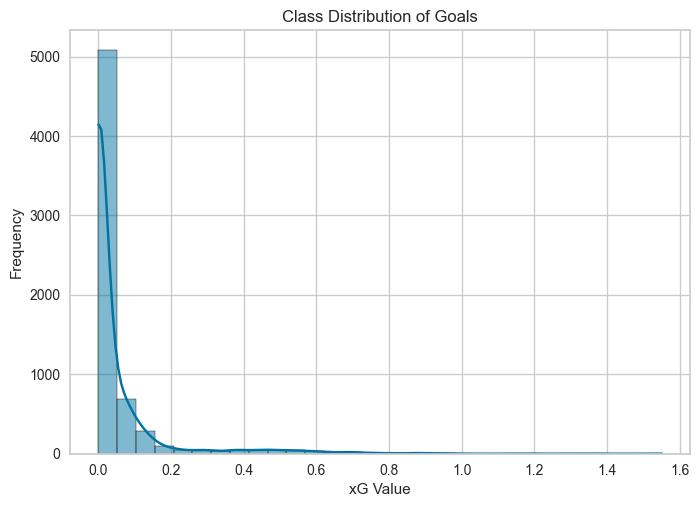

In [7]:
print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

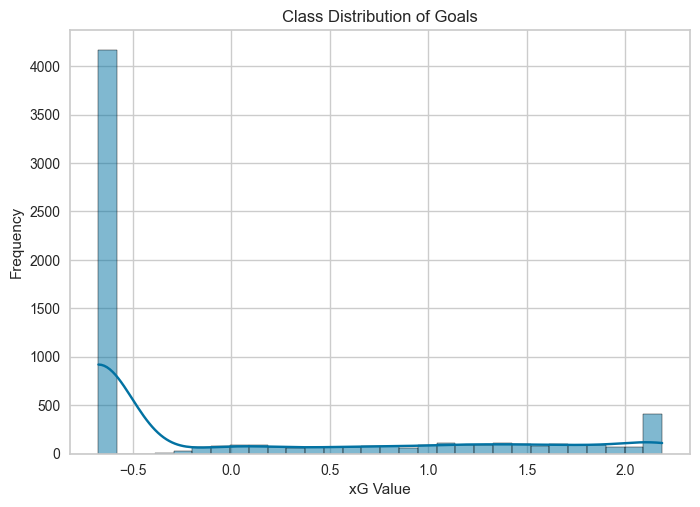

In [8]:
pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(def_xg_data[['xG']])

def_xg_data['xG'] = pt.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [9]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6153
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 86
[LightGBM] [Info] Start training from score -0.008052


,Description,Value
0,Session id,5073
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 147)"
4,Transformed data shape,"(6573, 30)"
5,Transformed train set shape,"(5258, 30)"
6,Transformed test set shape,"(1315, 30)"
7,Numeric features,145
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3159,0.2920,0.5399,0.7056,0.2415,1.5987,5.7260
et,Extra Trees Regressor,0.3193,0.2915,0.5393,0.7063,0.2451,1.5700,4.1790
lightgbm,Light Gradient Boosting Machine,0.3297,0.3014,0.5485,0.6962,0.2499,1.4508,2.9260
gbr,Gradient Boosting Regressor,0.3331,0.2937,0.5413,0.7040,0.2502,1.5147,4.3530
xgboost,Extreme Gradient Boosting,0.3588,0.3308,0.5744,0.6669,0.2519,1.8307,2.2430
ada,AdaBoost Regressor,0.3829,0.3279,0.5720,0.6695,0.2412,1.7265,1.5090
dt,Decision Tree Regressor,0.3841,0.5574,0.7460,0.4374,0.2613,2.1152,1.5640
huber,Huber Regressor,0.4400,0.5104,0.7133,0.4860,0.3255,1.3461,3.4460
knn,K Neighbors Regressor,0.4485,0.4880,0.6979,0.5081,0.3053,1.4735,2.0080
ridge,Ridge Regression,0.5122,0.4717,0.6858,0.5248,0.3531,1.2856,1.4930


RandomForestRegressor(n_jobs=-1, random_state=5073)

In [10]:
evaluate_model(base_def_xg_best,)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

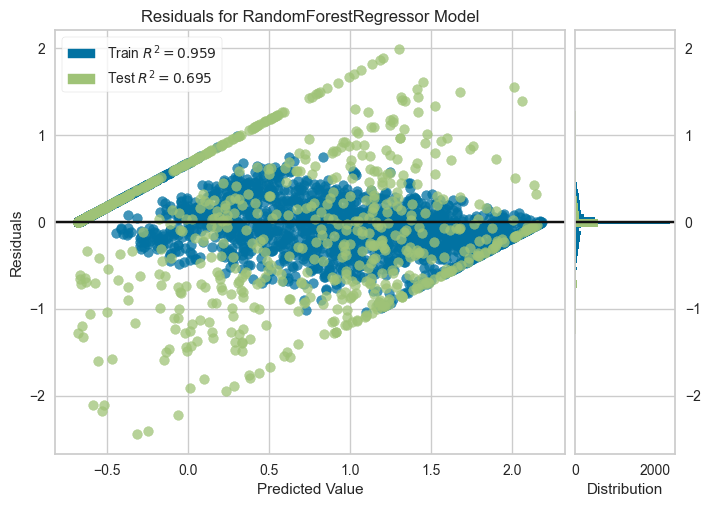

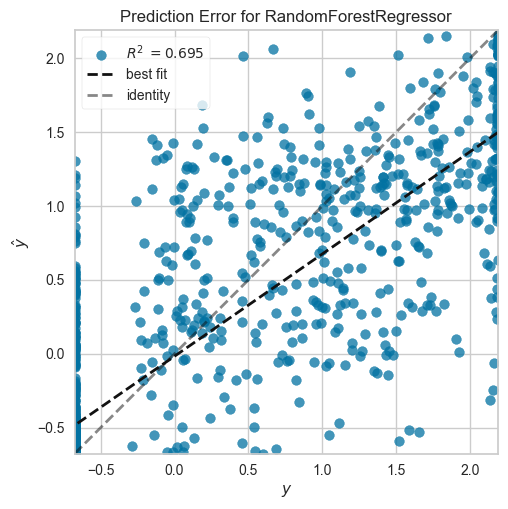

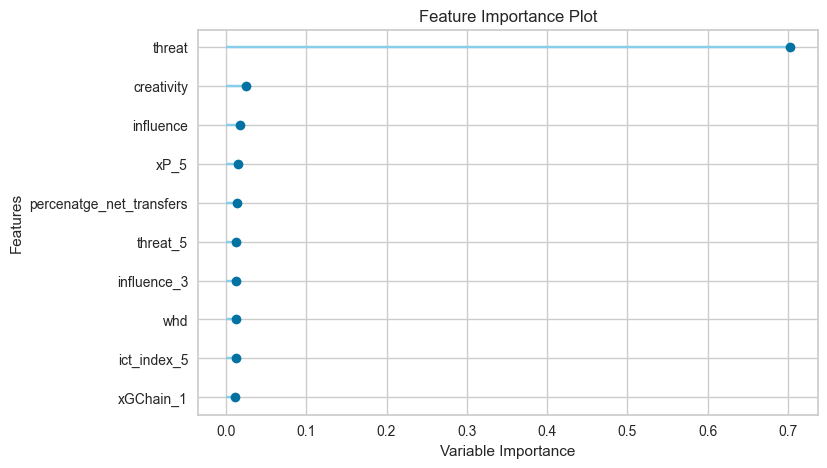

In [11]:
plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Blended Model


In [12]:
blend_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xg_best = compare_models(n_select=3, sort='MAE')
print(def_xg_best)

print('Blended model')
# Ensemble (blend or stack)
def_xg_blended = blend_models(def_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6399
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 88
[LightGBM] [Info] Start training from score 0.001559


,Description,Value
0,Session id,7729
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 147)"
4,Transformed data shape,"(6573, 30)"
5,Transformed train set shape,"(5258, 30)"
6,Transformed test set shape,"(1315, 30)"
7,Numeric features,145
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3160,0.2888,0.5366,0.7099,0.2415,1.9436,3.6060
rf,Random Forest Regressor,0.3173,0.2946,0.5418,0.7041,0.2414,1.8370,6.5200
lightgbm,Light Gradient Boosting Machine,0.3242,0.2917,0.5390,0.7072,0.2435,1.7422,3.9710
gbr,Gradient Boosting Regressor,0.3333,0.2920,0.5395,0.7065,0.2465,1.7418,3.8200
xgboost,Extreme Gradient Boosting,0.3543,0.3231,0.5673,0.6754,0.2506,1.7366,3.7480
ada,AdaBoost Regressor,0.3770,0.3237,0.5685,0.6747,0.2374,1.9472,2.3010
dt,Decision Tree Regressor,0.3917,0.5628,0.7488,0.4346,0.2683,2.5237,1.8500
huber,Huber Regressor,0.4407,0.5070,0.7110,0.4921,0.3244,1.2787,2.5460
knn,K Neighbors Regressor,0.4651,0.5051,0.7099,0.4934,0.3087,1.5178,1.9950
lr,Linear Regression,0.5102,0.4679,0.6833,0.5311,0.3522,1.2624,1.8120


[ExtraTreesRegressor(n_jobs=-1, random_state=7729), RandomForestRegressor(n_jobs=-1, random_state=7729), LGBMRegressor(n_jobs=-1, random_state=7729)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3291,0.3063,0.5535,0.6827,0.2531,1.1037
1,0.3534,0.3478,0.5898,0.6746,0.2592,1.2339
2,0.2944,0.2372,0.4870,0.7563,0.2272,1.2614
3,0.2850,0.2376,0.4874,0.7736,0.2190,1.0656
4,0.3336,0.3060,0.5532,0.7188,0.2419,0.6465
5,0.3225,0.3029,0.5503,0.7198,0.2457,2.8117
6,0.3080,0.2645,0.5143,0.7243,0.2437,1.1550
7,0.3100,0.2737,0.5232,0.6843,0.2281,1.4553
8,0.3162,0.2984,0.5462,0.7031,0.2493,2.3002


### Save Model


In [13]:
# # Patch method to prevent column reordering errors
# def _reorder_cols(self, df, original_df):
#     # Just return df without modifying columns
#     return df

# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [14]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

In [15]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

xG
0.000000    2501
0.761169      11
0.761169       3
0.052510       2
0.423129       1
            ... 
0.103368       1
0.078944       1
0.051074       1
0.104148       1
0.036180       1
Name: count, Length: 4563, dtype: int64


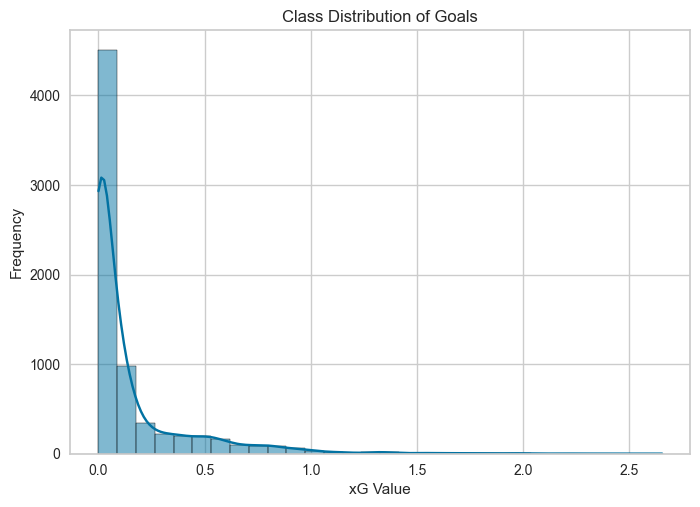

In [16]:
print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

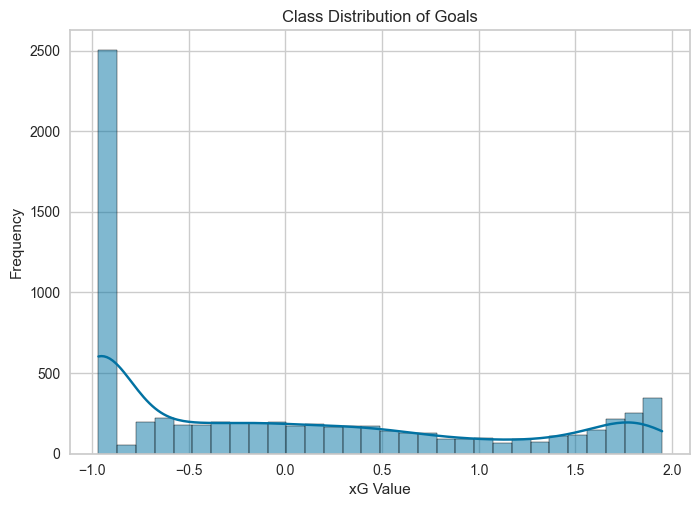

In [17]:
pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(mid_xg_data[['xG']])

mid_xg_data['xG'] = pt.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [18]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE', n_select=1)
base_mid_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7138
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 81
[LightGBM] [Info] Start training from score -0.009010


,Description,Value
0,Session id,2161
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 147)"
4,Transformed data shape,"(7076, 30)"
5,Transformed train set shape,"(5660, 30)"
6,Transformed test set shape,"(1416, 30)"
7,Numeric features,145
8,Rows with missing values,16.8%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3641,0.2794,0.5283,0.7160,0.2622,30.3336,13.3780
et,Extra Trees Regressor,0.3702,0.2821,0.5308,0.7133,0.2623,31.4805,5.9180
gbr,Gradient Boosting Regressor,0.3702,0.2739,0.5231,0.7216,0.2575,28.9293,3.5290
lightgbm,Light Gradient Boosting Machine,0.3718,0.2823,0.5310,0.7130,0.2594,31.9467,2.8090
xgboost,Extreme Gradient Boosting,0.4023,0.3166,0.5625,0.6781,0.2695,43.6904,2.0450
ada,AdaBoost Regressor,0.4393,0.3176,0.5631,0.6779,0.2818,32.6939,3.9130
knn,K Neighbors Regressor,0.4613,0.3974,0.6301,0.5963,0.2917,23.6924,2.2990
huber,Huber Regressor,0.4638,0.4104,0.6401,0.5838,0.2916,29.1717,4.3970
lr,Linear Regression,0.4779,0.3825,0.6182,0.6117,0.3020,23.7310,4.0540
ridge,Ridge Regression,0.4782,0.3826,0.6182,0.6117,0.3021,23.7353,1.8620


RandomForestRegressor(n_jobs=-1, random_state=2161)

In [19]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

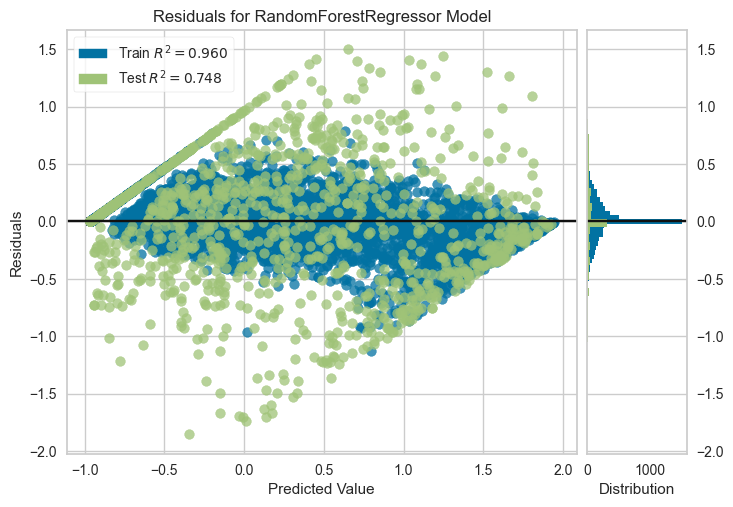

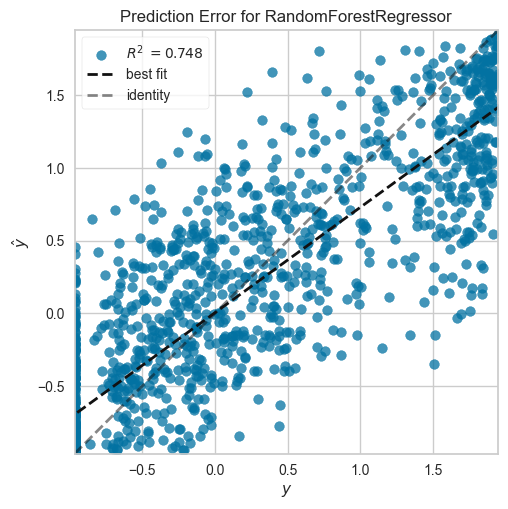

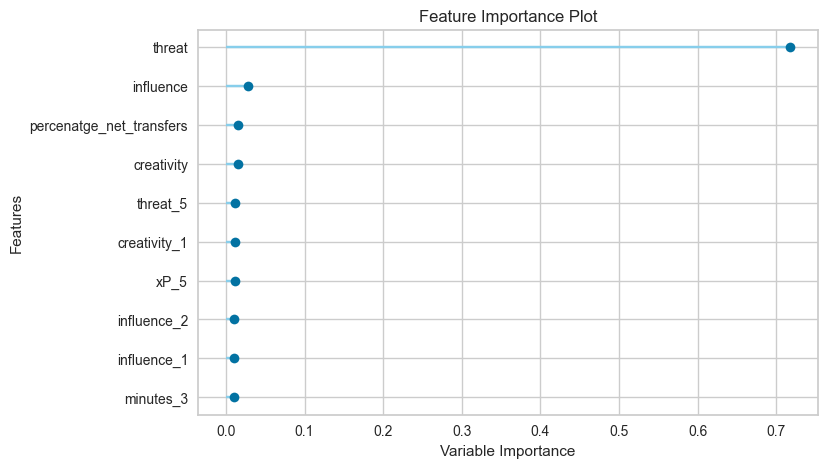

In [20]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Blended Model


In [21]:
blend_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xg_best = compare_models(n_select=3, sort='MAE')
print(mid_xg_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xg_blended = blend_models(mid_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7431
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 81
[LightGBM] [Info] Start training from score -0.004468


,Description,Value
0,Session id,919
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 147)"
4,Transformed data shape,"(7076, 30)"
5,Transformed train set shape,"(5660, 30)"
6,Transformed test set shape,"(1416, 30)"
7,Numeric features,145
8,Rows with missing values,16.8%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3658,0.2800,0.5288,0.7193,0.2615,27.6092,7.6810
et,Extra Trees Regressor,0.3694,0.2799,0.5287,0.7193,0.2608,29.9986,3.6400
gbr,Gradient Boosting Regressor,0.3708,0.2723,0.5214,0.7270,0.2578,28.5244,3.3510
lightgbm,Light Gradient Boosting Machine,0.3715,0.2800,0.5287,0.7192,0.2580,34.3104,3.2170
xgboost,Extreme Gradient Boosting,0.3949,0.3083,0.5545,0.6910,0.2657,15.3918,2.9900
ada,AdaBoost Regressor,0.4396,0.3113,0.5574,0.6877,0.2766,30.2705,2.0550
knn,K Neighbors Regressor,0.4580,0.3877,0.6220,0.6115,0.2927,24.1397,1.4470
huber,Huber Regressor,0.4674,0.4125,0.6415,0.5867,0.2919,28.3829,2.2000
dt,Decision Tree Regressor,0.4833,0.5547,0.7442,0.4433,0.3117,11.6940,1.7790
lr,Linear Regression,0.4833,0.3858,0.6206,0.6132,0.3043,21.5994,1.6570


[RandomForestRegressor(n_jobs=-1, random_state=919), ExtraTreesRegressor(n_jobs=-1, random_state=919), GradientBoostingRegressor(random_state=919)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3739,0.2603,0.5102,0.7291,0.2611,1.2771
1,0.3673,0.2655,0.5153,0.7437,0.2442,1.6589
2,0.3551,0.2610,0.5109,0.7442,0.2624,1.5993
3,0.3882,0.3171,0.5631,0.6992,0.2717,1.6632
4,0.3448,0.2423,0.4922,0.7531,0.2567,1.9566
5,0.3729,0.2926,0.5409,0.6940,0.2628,270.1162
6,0.3605,0.2595,0.5094,0.7366,0.2618,1.9681
7,0.3754,0.2867,0.5354,0.7057,0.2757,1.7634
8,0.3668,0.2707,0.5203,0.7253,0.2588,3.6181


### Save Model


In [22]:
mid_xg_final_model = finalize_model(mid_xg_blended)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                               

## For


xG
0.000000    290
0.761169      7
0.208655      1
0.582700      1
0.366415      1
           ... 
0.583476      1
0.125661      1
1.442925      1
0.616388      1
0.326243      1
Name: count, Length: 1295, dtype: int64


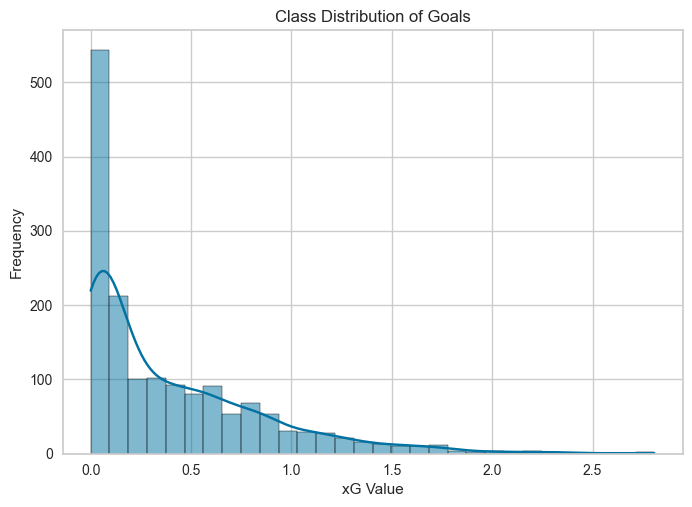

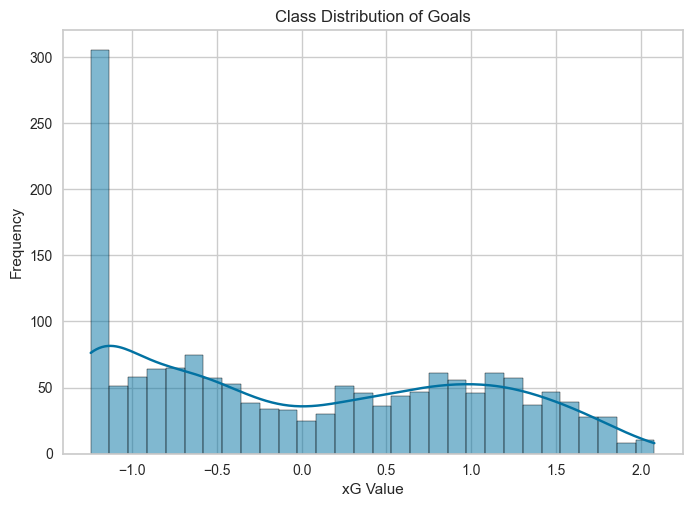

In [23]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(fwd_xg_data[['xG']])

fwd_xg_data['xG'] = pt.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6600
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.025458


,Description,Value
0,Session id,3291
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 147)"
4,Transformed data shape,"(1590, 30)"
5,Transformed train set shape,"(1272, 30)"
6,Transformed test set shape,"(318, 30)"
7,Numeric features,145
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4411,0.3214,0.5665,0.6778,0.2708,1.1570,2.7830
rf,Random Forest Regressor,0.4457,0.3370,0.5798,0.6626,0.2730,1.1435,3.1290
lightgbm,Light Gradient Boosting Machine,0.4460,0.3384,0.5810,0.6605,0.2657,1.2150,4.5150
et,Extra Trees Regressor,0.4491,0.3384,0.5810,0.6611,0.2773,1.1058,3.3510
xgboost,Extreme Gradient Boosting,0.4695,0.3826,0.6176,0.6160,0.2761,1.1381,3.2510
knn,K Neighbors Regressor,0.5107,0.4301,0.6556,0.5697,0.2970,1.3224,6.2960
huber,Huber Regressor,0.5126,0.4234,0.6494,0.5777,0.2856,1.1331,3.3910
lr,Linear Regression,0.5166,0.3931,0.6264,0.6072,0.2968,1.0920,1.5290
ridge,Ridge Regression,0.5167,0.3928,0.6261,0.6075,0.2970,1.0949,1.5860
br,Bayesian Ridge,0.5188,0.3959,0.6285,0.6045,0.2981,1.0758,1.3250


GradientBoostingRegressor(random_state=3291)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


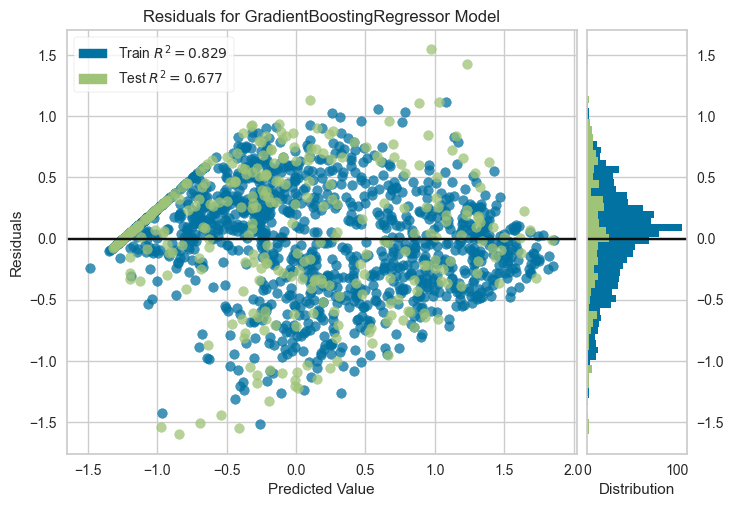

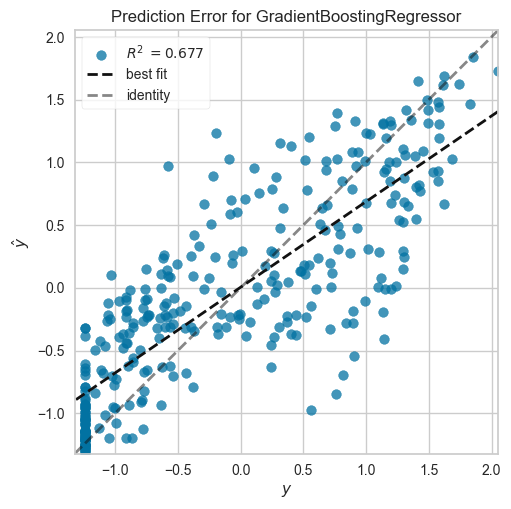

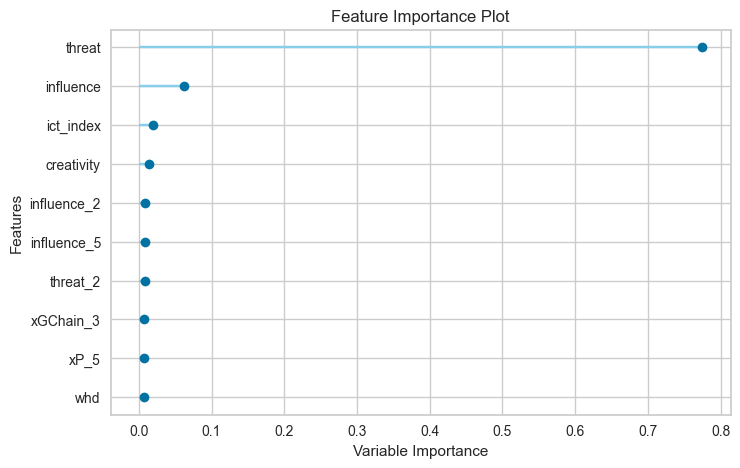

In [24]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Blended Model


In [25]:
blend_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xg_best = compare_models(n_select=3, sort='MAE')
print(fwd_xg_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xg_blended = blend_models(fwd_xg_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.140669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6851
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 83
[LightGBM] [Info] Start training from score 0.001119


,Description,Value
0,Session id,5118
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 147)"
4,Transformed data shape,"(1590, 30)"
5,Transformed train set shape,"(1272, 30)"
6,Transformed test set shape,"(318, 30)"
7,Numeric features,145
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4474,0.3317,0.5751,0.6606,0.2745,1.2104,1.4830
rf,Random Forest Regressor,0.4497,0.3421,0.5844,0.6501,0.2788,1.1660,2.3460
et,Extra Trees Regressor,0.4499,0.3389,0.5817,0.6532,0.2828,1.1248,2.0750
lightgbm,Light Gradient Boosting Machine,0.4553,0.3531,0.5931,0.6381,0.2726,1.3005,1.4770
xgboost,Extreme Gradient Boosting,0.4657,0.3761,0.6118,0.6146,0.2756,1.2484,1.4270
knn,K Neighbors Regressor,0.5055,0.4197,0.6472,0.5709,0.2952,1.3059,0.8830
huber,Huber Regressor,0.5074,0.4179,0.6450,0.5700,0.2879,1.1555,1.2670
ridge,Ridge Regression,0.5117,0.3899,0.6236,0.6000,0.2998,1.1441,1.1400
lr,Linear Regression,0.5120,0.3909,0.6244,0.5989,0.2997,1.1408,1.7950
br,Bayesian Ridge,0.5142,0.3912,0.6245,0.5985,0.3000,1.1337,0.8080


[GradientBoostingRegressor(random_state=5118), RandomForestRegressor(n_jobs=-1, random_state=5118), ExtraTreesRegressor(n_jobs=-1, random_state=5118)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4297,0.3325,0.5766,0.6357,0.2705,0.8633
1,0.4380,0.3343,0.5782,0.6135,0.2879,0.8140
2,0.3976,0.2860,0.5347,0.7210,0.2749,0.9269
3,0.4528,0.3406,0.5836,0.6362,0.2807,2.2601
4,0.4360,0.3124,0.5589,0.6806,0.2775,1.5923
5,0.4985,0.3803,0.6167,0.6178,0.3079,0.9328
6,0.4219,0.2985,0.5463,0.7447,0.2609,0.7659
7,0.4592,0.3672,0.6059,0.6503,0.2729,0.8218
8,0.4504,0.3239,0.5691,0.6433,0.2725,1.0848


### Save Model


In [26]:
fwd_xg_final_model = finalize_model(base_fwd_xg_best)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [27]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2',
            'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    4470
0.059942       2
0.063347       1
0.108050       1
0.049833       1
            ... 
0.016065       1
0.037171       1
0.023500       1
0.013137       1
0.549479       1
Name: count, Length: 2103, dtype: int64


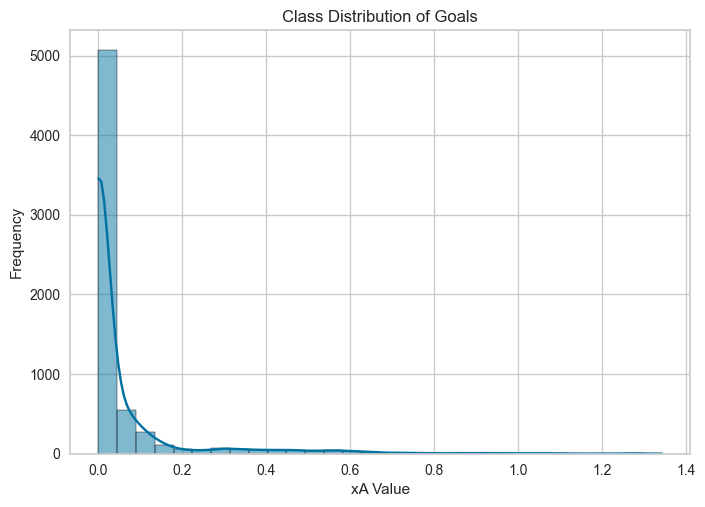

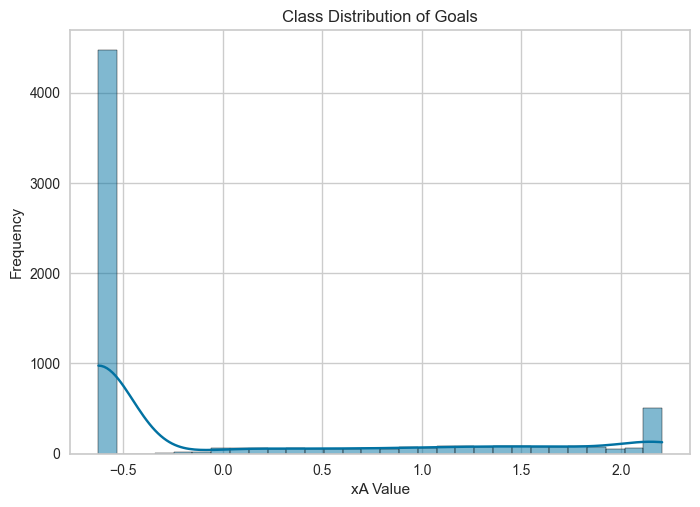

In [28]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(def_xa_data[['xA']])

def_xa_data['xA'] = pt.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6354
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 79
[LightGBM] [Info] Start training from score 0.007085


,Description,Value
0,Session id,5572
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 118)"
4,Transformed data shape,"(6573, 24)"
5,Transformed train set shape,"(5258, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,116
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.2004,0.1803,0.4243,0.8201,0.1859,0.9943,4.2330
et,Extra Trees Regressor,0.2026,0.1756,0.4188,0.8247,0.1861,0.9736,2.1990
gbr,Gradient Boosting Regressor,0.2064,0.1745,0.4175,0.8258,0.1843,1.0154,2.2980
lightgbm,Light Gradient Boosting Machine,0.2109,0.1858,0.4307,0.8144,0.1941,0.9764,2.5240
ada,AdaBoost Regressor,0.2192,0.1866,0.4318,0.8139,0.1911,1.0327,1.6820
xgboost,Extreme Gradient Boosting,0.2331,0.2139,0.4619,0.7871,0.2066,1.0133,1.7810
knn,K Neighbors Regressor,0.2543,0.2606,0.5099,0.7404,0.2333,0.9768,1.3800
dt,Decision Tree Regressor,0.2574,0.3441,0.5848,0.6538,0.2486,1.0628,1.3940
huber,Huber Regressor,0.3377,0.3760,0.6109,0.6288,0.2805,0.6328,1.1270
ridge,Ridge Regression,0.3927,0.3590,0.5974,0.6452,0.2852,0.7499,0.7160


RandomForestRegressor(n_jobs=-1, random_state=5572)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


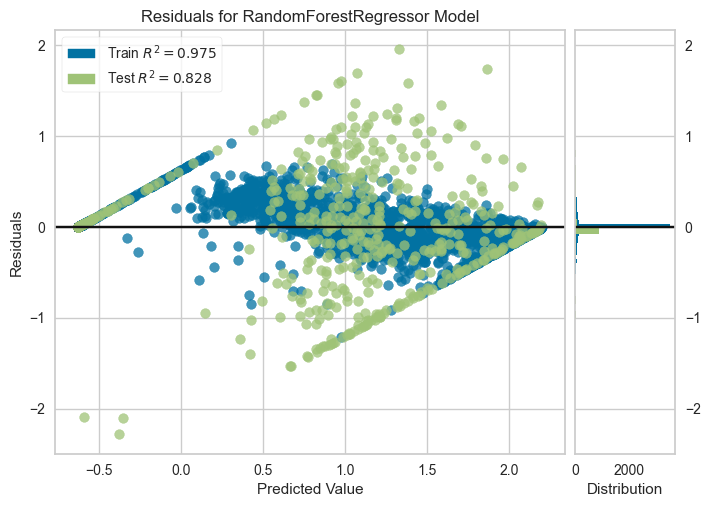

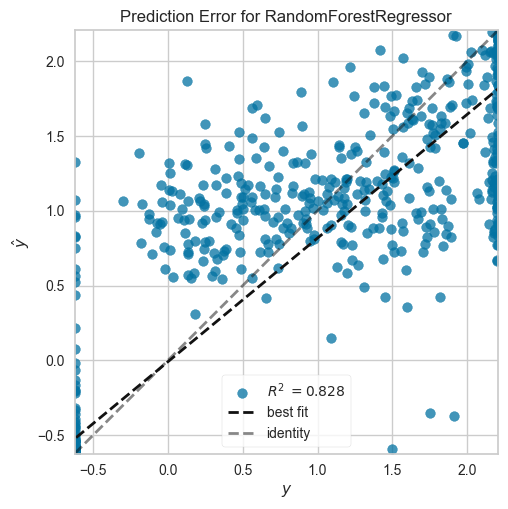

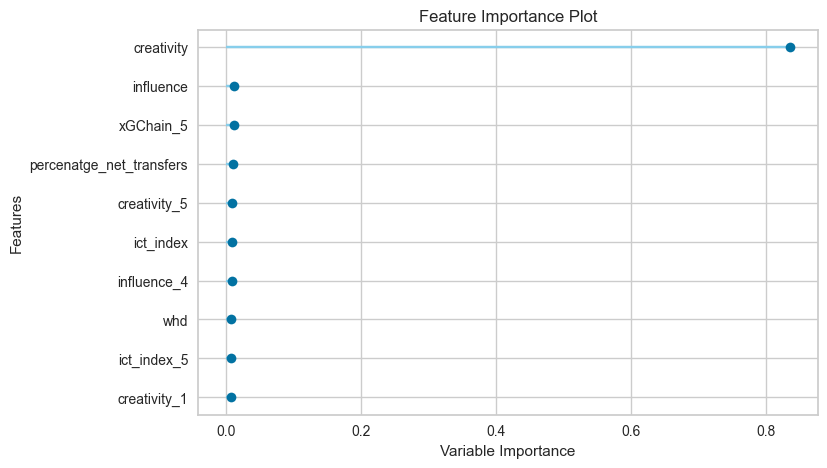

In [29]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Blended Model


In [30]:
blend_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xa_best = compare_models(n_select=3, sort='MAE')
print(def_xa_best)

print('Blended model')
# Ensemble (blend or stack)
def_xa_blended = blend_models(def_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5971
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 76
[LightGBM] [Info] Start training from score 0.004671


,Description,Value
0,Session id,2385
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 118)"
4,Transformed data shape,"(6573, 24)"
5,Transformed train set shape,"(5258, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,116
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1918,0.1672,0.4078,0.8327,0.1838,0.9495,4.2570
et,Extra Trees Regressor,0.1955,0.1654,0.4055,0.8344,0.1845,0.9893,2.4370
gbr,Gradient Boosting Regressor,0.1993,0.1654,0.4054,0.8344,0.1824,0.9814,2.5410
lightgbm,Light Gradient Boosting Machine,0.2031,0.1731,0.4149,0.8269,0.1902,0.9561,2.0090
ada,AdaBoost Regressor,0.2052,0.1731,0.4151,0.8264,0.1900,0.9902,1.4870
xgboost,Extreme Gradient Boosting,0.2226,0.1946,0.4402,0.8051,0.1993,0.9592,1.7730
knn,K Neighbors Regressor,0.2403,0.2375,0.4867,0.7619,0.2249,0.9059,1.4340
dt,Decision Tree Regressor,0.2612,0.3420,0.5844,0.6562,0.2567,1.1167,1.0070
huber,Huber Regressor,0.3331,0.3888,0.6215,0.6111,0.2810,0.6024,1.1220
ridge,Ridge Regression,0.3983,0.3661,0.6037,0.6335,0.2897,0.7411,1.0220


[RandomForestRegressor(n_jobs=-1, random_state=2385), ExtraTreesRegressor(n_jobs=-1, random_state=2385), GradientBoostingRegressor(random_state=2385)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1959,0.1565,0.3956,0.8580,0.1797,0.6594
1,0.2024,0.1718,0.4145,0.8366,0.1828,0.7722
2,0.1979,0.1682,0.4101,0.8128,0.1954,1.9028
3,0.1956,0.1780,0.4219,0.8211,0.1790,1.1009
4,0.1938,0.1565,0.3956,0.8418,0.1826,0.8817
5,0.2065,0.1849,0.4300,0.8218,0.1900,1.3700
6,0.2234,0.1834,0.4282,0.8236,0.2004,0.9205
7,0.1509,0.1126,0.3356,0.8737,0.1614,0.6865
8,0.2114,0.1865,0.4318,0.8192,0.1962,1.0957


### Save Model


In [31]:
def_xa_final_model = finalize_model(def_xa_blended)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## Mid


xA
0.000000    2859
0.107738       2
0.095407       1
0.023504       1
0.403232       1
            ... 
0.454983       1
0.081762       1
0.106337       1
0.115025       1
0.043413       1
Name: count, Length: 4217, dtype: int64


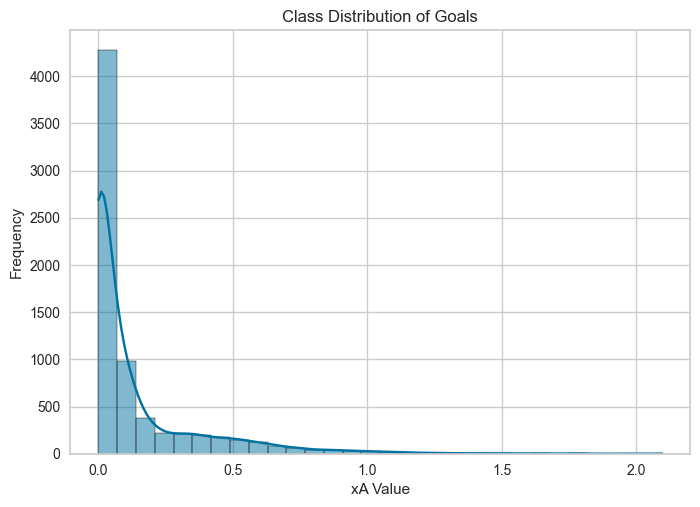

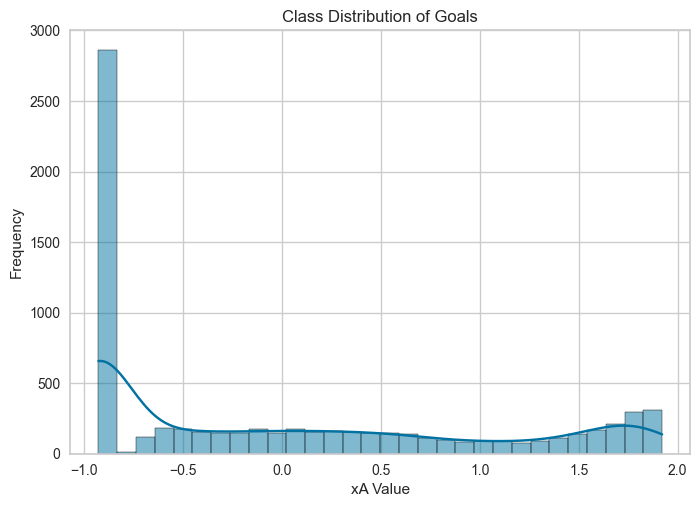

In [32]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(mid_xa_data[['xA']])

mid_xa_data['xA'] = pt.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008883 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7364
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 76
[LightGBM] [Info] Start training from score 0.005843


,Description,Value
0,Session id,7459
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 118)"
4,Transformed data shape,"(7076, 24)"
5,Transformed train set shape,"(5660, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,116
8,Rows with missing values,16.8%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3467,0.2953,0.5430,0.7044,0.2641,1.3421,8.3850
et,Extra Trees Regressor,0.3513,0.2935,0.5413,0.7063,0.2664,1.3202,4.0940
gbr,Gradient Boosting Regressor,0.3543,0.2869,0.5351,0.7128,0.2729,1.2466,4.2640
lightgbm,Light Gradient Boosting Machine,0.3579,0.2990,0.5463,0.7007,0.2665,1.3547,2.1340
ada,AdaBoost Regressor,0.3914,0.3145,0.5602,0.6852,0.2427,1.6642,1.6350
xgboost,Extreme Gradient Boosting,0.3932,0.3362,0.5793,0.6635,0.2692,1.4776,1.8420
knn,K Neighbors Regressor,0.4269,0.3973,0.6299,0.6027,0.2875,1.5742,1.6200
huber,Huber Regressor,0.4327,0.4182,0.6462,0.5818,0.2956,1.2022,3.8870
dt,Decision Tree Regressor,0.4483,0.5531,0.7423,0.4459,0.3053,2.5094,1.7790
ridge,Ridge Regression,0.4653,0.3939,0.6272,0.6061,0.3095,1.1334,1.2150


RandomForestRegressor(n_jobs=-1, random_state=7459)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


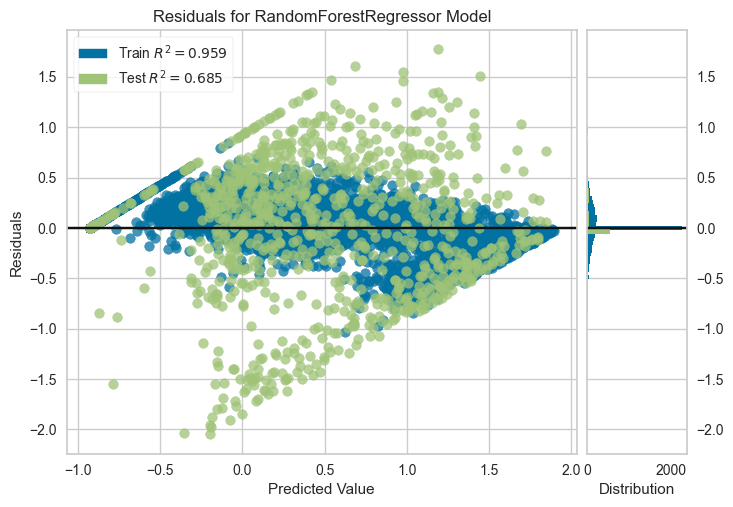

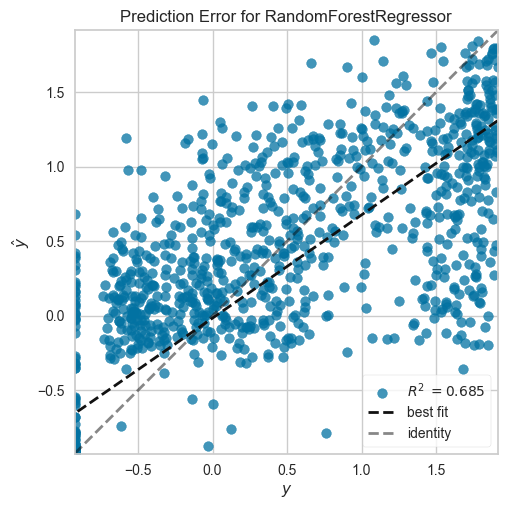

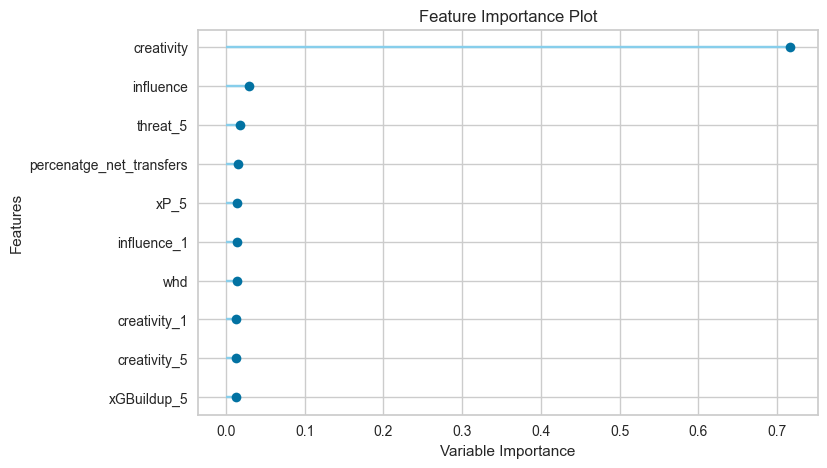

In [33]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Blended model


In [34]:
blend_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xa_best = compare_models(n_select=3, sort='MAE')
print(mid_xa_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xa_blended = blend_models(mid_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7352
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 77
[LightGBM] [Info] Start training from score 0.008987


,Description,Value
0,Session id,6287
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 118)"
4,Transformed data shape,"(7076, 24)"
5,Transformed train set shape,"(5660, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,116
8,Rows with missing values,16.8%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3508,0.3003,0.5477,0.7006,0.2665,1.2638,5.1650
et,Extra Trees Regressor,0.3566,0.3024,0.5496,0.6986,0.2696,1.2813,2.7240
gbr,Gradient Boosting Regressor,0.3597,0.2951,0.5428,0.7060,0.2763,1.2254,2.3080
lightgbm,Light Gradient Boosting Machine,0.3622,0.3055,0.5522,0.6956,0.2674,1.3192,2.1720
ada,AdaBoost Regressor,0.3933,0.3274,0.5720,0.6736,0.2469,1.5410,1.7180
xgboost,Extreme Gradient Boosting,0.3947,0.3376,0.5806,0.6635,0.2742,1.4221,2.0690
knn,K Neighbors Regressor,0.4327,0.4055,0.6366,0.5958,0.2922,1.5372,2.3400
huber,Huber Regressor,0.4419,0.4329,0.6574,0.5689,0.3017,1.1345,1.4540
dt,Decision Tree Regressor,0.4542,0.5655,0.7516,0.4353,0.3150,2.1754,1.8190
lr,Linear Regression,0.4740,0.4062,0.6369,0.5955,0.3157,1.1050,1.6080


[RandomForestRegressor(n_jobs=-1, random_state=6287), ExtraTreesRegressor(n_jobs=-1, random_state=6287), GradientBoostingRegressor(random_state=6287)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3679,0.3073,0.5544,0.7190,0.2848,0.9634
1,0.3265,0.2597,0.5096,0.7437,0.2564,1.1685
2,0.3318,0.2604,0.5103,0.7343,0.2580,1.6451
3,0.3616,0.2999,0.5476,0.6991,0.2657,1.3133
4,0.3456,0.2775,0.5268,0.7057,0.2711,1.0502
5,0.3607,0.3209,0.5665,0.6703,0.2761,1.1588
6,0.3509,0.2901,0.5386,0.7113,0.2585,1.1614
7,0.3672,0.3202,0.5659,0.7008,0.2817,1.3418
8,0.3580,0.2954,0.5435,0.7080,0.2690,1.2763


### Save Model


In [35]:
mid_xa_final_model = finalize_model(mid_xa_blended)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## For


xA
0.000000    767
0.127663      1
0.077458      1
0.147103      1
0.733360      1
           ... 
0.414716      1
0.122116      1
0.031267      1
0.401950      1
0.048869      1
Name: count, Length: 824, dtype: int64


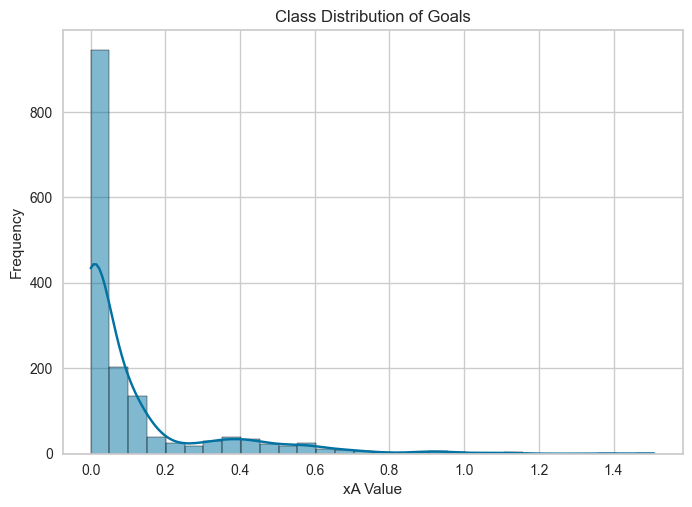

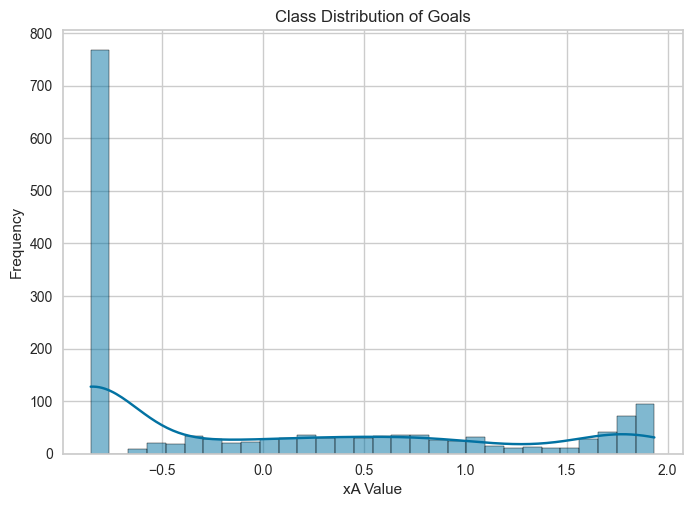

In [36]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(fwd_xa_data[['xA']])

fwd_xa_data['xA'] = pt.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7202
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.001251


,Description,Value
0,Session id,2539
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 118)"
4,Transformed data shape,"(1590, 24)"
5,Transformed train set shape,"(1272, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,116
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3127,0.2713,0.5164,0.7244,0.2343,1.0713,5.9320
et,Extra Trees Regressor,0.3175,0.2693,0.5149,0.7261,0.2335,1.0617,5.9040
gbr,Gradient Boosting Regressor,0.3293,0.2684,0.5139,0.7276,0.2354,1.0877,2.8480
lightgbm,Light Gradient Boosting Machine,0.3368,0.2912,0.5358,0.7044,0.2423,1.1014,1.5830
xgboost,Extreme Gradient Boosting,0.3513,0.3153,0.5559,0.6807,0.2539,1.1311,1.6550
dt,Decision Tree Regressor,0.3845,0.4711,0.6809,0.5207,0.2839,1.3293,2.1360
huber,Huber Regressor,0.4030,0.3783,0.6122,0.6175,0.2959,0.7923,0.8190
br,Bayesian Ridge,0.4277,0.3620,0.5992,0.6333,0.3022,0.8037,0.8960
ridge,Ridge Regression,0.4288,0.3664,0.6029,0.6288,0.3028,0.8070,0.9260
lr,Linear Regression,0.4296,0.3673,0.6037,0.6278,0.3030,0.8082,0.8800


RandomForestRegressor(n_jobs=-1, random_state=2539)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


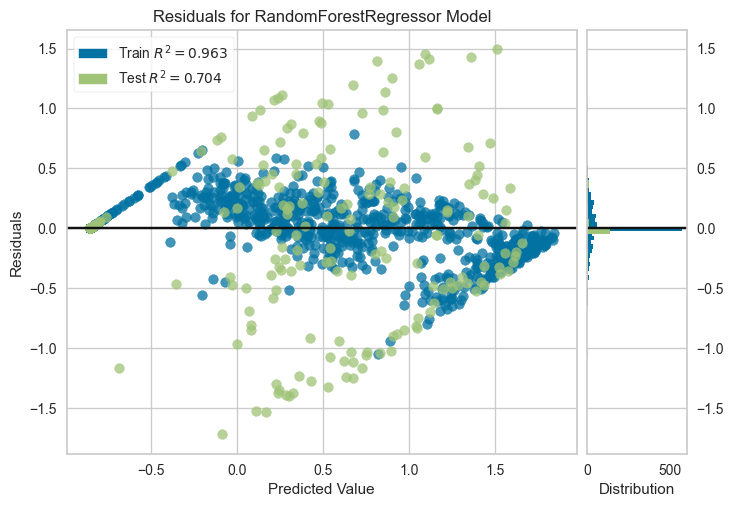

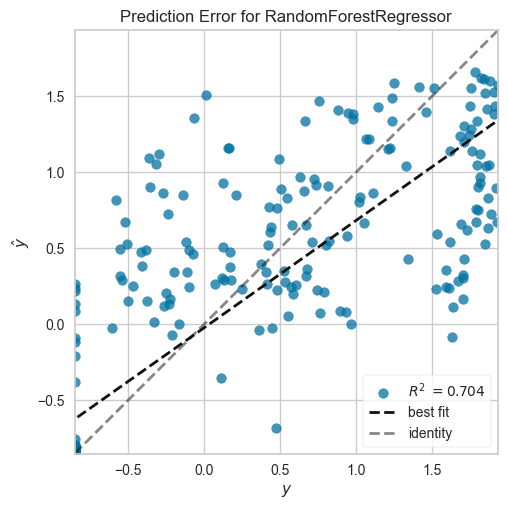

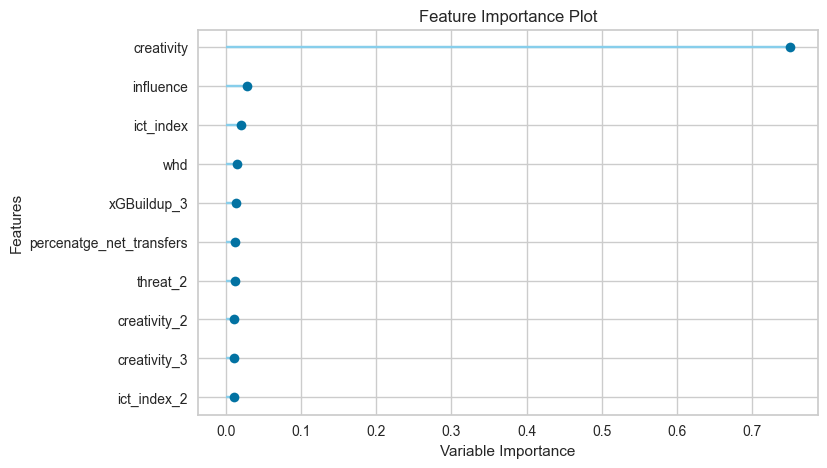

In [37]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Blended model


In [38]:
blend_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xa_best = compare_models(n_select=3, sort='MAE')
print(fwd_xa_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xa_blended = blend_models(fwd_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003954 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7105
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.015309


,Description,Value
0,Session id,2098
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 118)"
4,Transformed data shape,"(1590, 24)"
5,Transformed train set shape,"(1272, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,116
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3135,0.2710,0.5180,0.7324,0.2344,1.1678,1.7310
et,Extra Trees Regressor,0.3135,0.2614,0.5084,0.7419,0.2318,1.1343,2.7860
gbr,Gradient Boosting Regressor,0.3284,0.2723,0.5179,0.7309,0.2335,1.1278,1.5360
lightgbm,Light Gradient Boosting Machine,0.3357,0.2838,0.5286,0.7198,0.2436,1.2167,1.8400
xgboost,Extreme Gradient Boosting,0.3487,0.3001,0.5433,0.7038,0.2476,1.2579,1.0990
dt,Decision Tree Regressor,0.3965,0.4981,0.7029,0.5063,0.2979,1.4007,1.1410
huber,Huber Regressor,0.4154,0.3897,0.6215,0.6157,0.3007,0.8417,1.0870
ridge,Ridge Regression,0.4390,0.3723,0.6078,0.6329,0.3079,0.8988,1.0540
lr,Linear Regression,0.4392,0.3725,0.6080,0.6327,0.3083,0.9014,0.9870
br,Bayesian Ridge,0.4394,0.3702,0.6060,0.6349,0.3076,0.8908,0.9820


[RandomForestRegressor(n_jobs=-1, random_state=2098), ExtraTreesRegressor(n_jobs=-1, random_state=2098), GradientBoostingRegressor(random_state=2098)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4090,0.3882,0.6231,0.6085,0.3076,2.4071
1,0.2942,0.2697,0.5193,0.7283,0.1864,0.5379
2,0.3443,0.2999,0.5476,0.7204,0.2366,1.1837
3,0.3077,0.2163,0.4651,0.7892,0.2071,0.8326
4,0.3452,0.3104,0.5572,0.7154,0.2594,0.9545
5,0.2495,0.1719,0.4146,0.8381,0.1902,1.3720
6,0.3017,0.2236,0.4729,0.7550,0.2411,1.5899
7,0.2897,0.2342,0.4839,0.7753,0.2258,0.6545
8,0.2881,0.2128,0.4613,0.7803,0.2125,0.6977


### Save Model


In [39]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     360
3     298
1     255
4     235
5     156
0     126
6      84
7      54
8      21
9      15
10      4
11      2
12      1
13      1
Name: count, dtype: int64


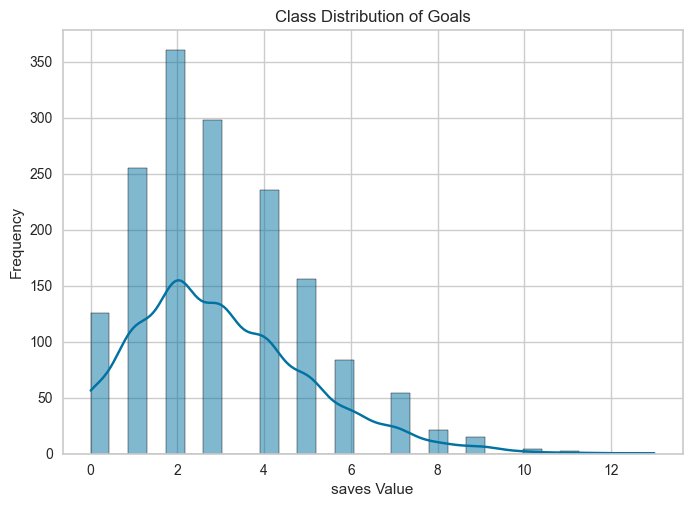

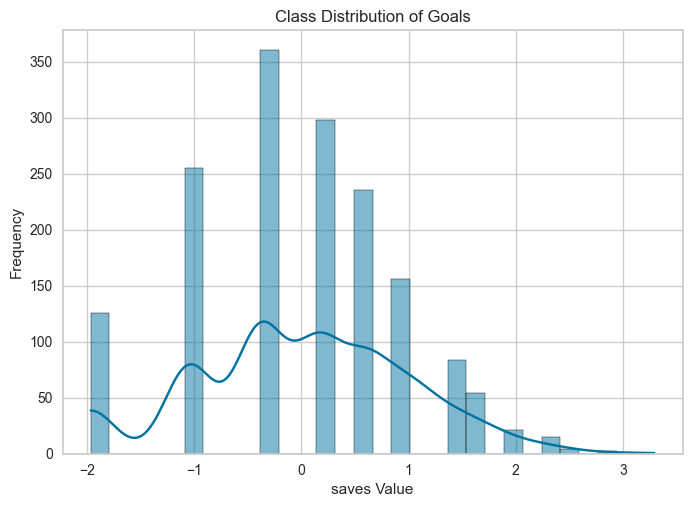

In [40]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(g_saves_data[['saves']])

g_saves_data['saves'] = pt.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3004
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 66
[LightGBM] [Info] Start training from score 0.015646


,Description,Value
0,Session id,6147
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1612, 24)"
5,Transformed train set shape,"(1289, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2790,0.1484,0.3833,0.8491,0.1899,0.6349,1.2010
rf,Random Forest Regressor,0.2865,0.1565,0.3938,0.8411,0.1928,0.6550,2.0920
et,Extra Trees Regressor,0.2879,0.1542,0.3911,0.8434,0.1923,0.6573,2.8160
lightgbm,Light Gradient Boosting Machine,0.2987,0.1651,0.4048,0.8326,0.2020,0.6888,0.7240
xgboost,Extreme Gradient Boosting,0.3104,0.1799,0.4227,0.8182,0.2092,0.7126,1.1840
br,Bayesian Ridge,0.3148,0.1852,0.4284,0.8122,0.2013,0.6865,0.7050
omp,Orthogonal Matching Pursuit,0.3156,0.1877,0.4313,0.8096,0.2011,0.6886,0.6110
ridge,Ridge Regression,0.3172,0.1861,0.4296,0.8112,0.2030,0.6938,0.5990
lr,Linear Regression,0.3175,0.1864,0.4299,0.8110,0.2030,0.6942,0.6960
en,Elastic Net,0.3186,0.1889,0.4330,0.8085,0.2038,0.6771,0.7010


GradientBoostingRegressor(random_state=6147)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


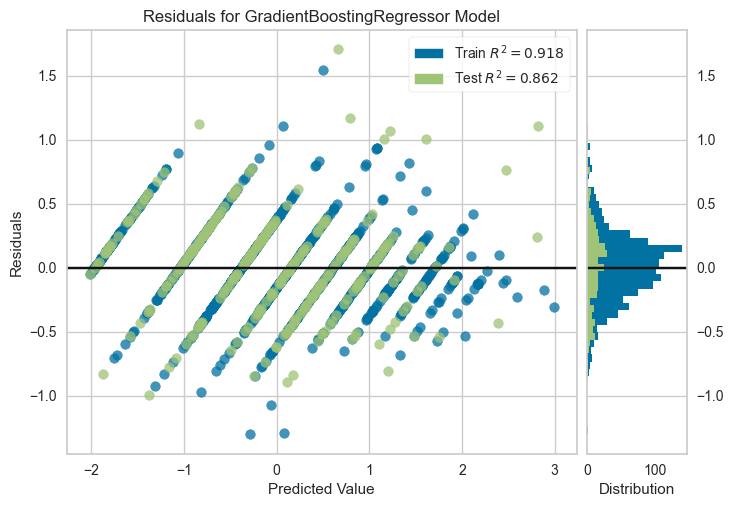

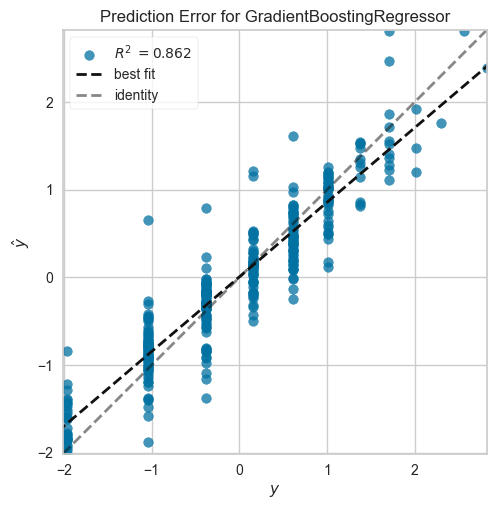

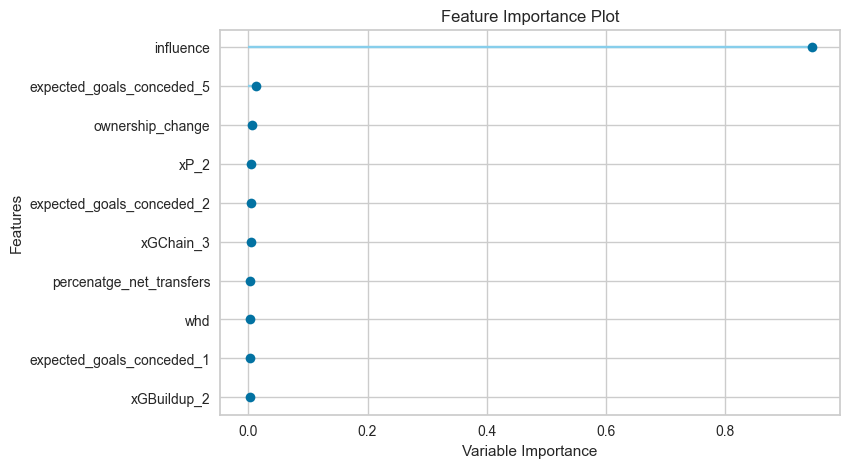

In [41]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Blended Model


In [42]:
blend_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_saves_best = compare_models(n_select=3, sort='MAE')
print(g_saves_best)

print('Blended model')
# Ensemble (blend or stack)
g_saves_blended = blend_models(g_saves_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004740 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2972
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 65
[LightGBM] [Info] Start training from score 0.002782


,Description,Value
0,Session id,1081
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1612, 24)"
5,Transformed train set shape,"(1289, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2769,0.1406,0.3737,0.8555,0.1894,0.6431,0.5920
rf,Random Forest Regressor,0.2822,0.1464,0.3816,0.8498,0.1911,0.6491,1.5840
lightgbm,Light Gradient Boosting Machine,0.2833,0.1498,0.3862,0.8462,0.1925,0.6741,0.4790
et,Extra Trees Regressor,0.2852,0.1466,0.3820,0.8493,0.1921,0.6538,1.4280
xgboost,Extreme Gradient Boosting,0.3010,0.1643,0.4046,0.8315,0.2028,0.6967,0.7680
br,Bayesian Ridge,0.3101,0.1734,0.4154,0.8230,0.2005,0.6647,0.7970
ridge,Ridge Regression,0.3113,0.1740,0.4161,0.8223,0.2016,0.6667,0.5150
lr,Linear Regression,0.3117,0.1741,0.4163,0.8221,0.2018,0.6668,1.0860
omp,Orthogonal Matching Pursuit,0.3117,0.1768,0.4195,0.8193,0.2000,0.6711,0.6210
en,Elastic Net,0.3155,0.1781,0.4212,0.8181,0.2027,0.6616,0.5600


[GradientBoostingRegressor(random_state=1081), RandomForestRegressor(n_jobs=-1, random_state=1081), LGBMRegressor(n_jobs=-1, random_state=1081)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2815,0.1393,0.3733,0.8290,0.1863,0.7267
1,0.2803,0.1671,0.4088,0.8617,0.2072,0.7503
2,0.3010,0.1669,0.4085,0.8141,0.1829,0.6654
3,0.2727,0.1316,0.3628,0.8859,0.1897,0.5154
4,0.2786,0.1751,0.4185,0.8153,0.1843,0.5574
5,0.2684,0.1305,0.3613,0.8711,0.1904,0.5904
6,0.2829,0.1329,0.3645,0.8579,0.1961,0.8477
7,0.2753,0.1284,0.3583,0.8479,0.1910,0.7136
8,0.2607,0.1207,0.3474,0.8752,0.1702,0.6251


### Save Model


In [43]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [44]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.48    19
0.83    17
1.03    14
1.32    13
1.12    13
        ..
3.22     1
2.62     1
3.52     1
3.70     1
3.60     1
Name: count, Length: 344, dtype: int64


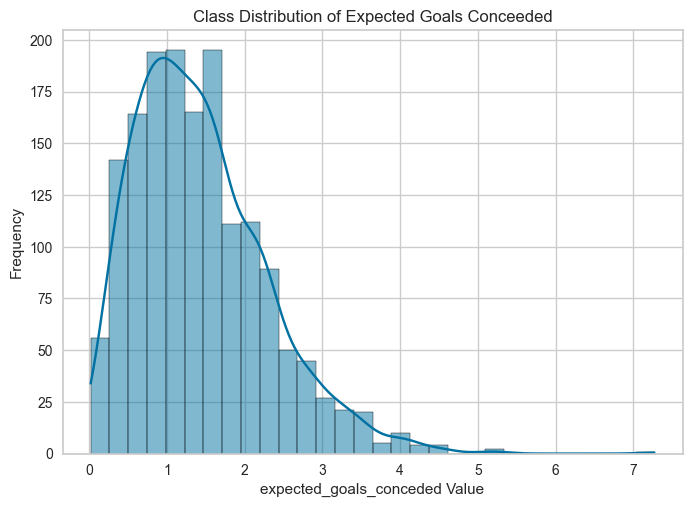

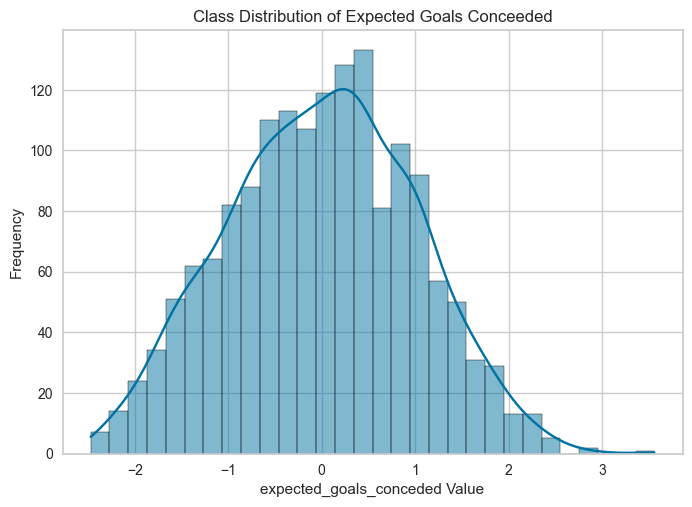

In [45]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(g_xgc_data[['expected_goals_conceded']])

g_xgc_data['expected_goals_conceded'] = pt.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3032
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 68
[LightGBM] [Info] Start training from score 0.023904


,Description,Value
0,Session id,3649
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 108)"
4,Transformed data shape,"(1612, 22)"
5,Transformed train set shape,"(1289, 22)"
6,Transformed test set shape,"(323, 22)"
7,Numeric features,106
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7090,0.7522,0.8660,0.2438,0.4010,1.7323,0.3600
lr,Linear Regression,0.7095,0.7536,0.8669,0.2424,0.4011,1.7389,0.3790
br,Bayesian Ridge,0.7115,0.7528,0.8662,0.2440,0.4068,1.6974,0.3550
gbr,Gradient Boosting Regressor,0.7165,0.7737,0.8784,0.2216,0.4083,1.7530,0.5330
et,Extra Trees Regressor,0.7177,0.7791,0.8814,0.2162,0.4072,1.7257,0.8360
rf,Random Forest Regressor,0.7189,0.7795,0.8816,0.2167,0.4156,1.7854,1.1890
ada,AdaBoost Regressor,0.7235,0.7755,0.8788,0.2245,0.4437,1.4669,0.5610
omp,Orthogonal Matching Pursuit,0.7374,0.8010,0.8934,0.1969,0.4225,1.6227,0.4340
en,Elastic Net,0.7380,0.8016,0.8936,0.1968,0.4302,1.5567,0.2650
llar,Lasso Least Angle Regression,0.7392,0.8055,0.8957,0.1935,0.4397,1.4935,0.5510


Ridge(random_state=3649)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


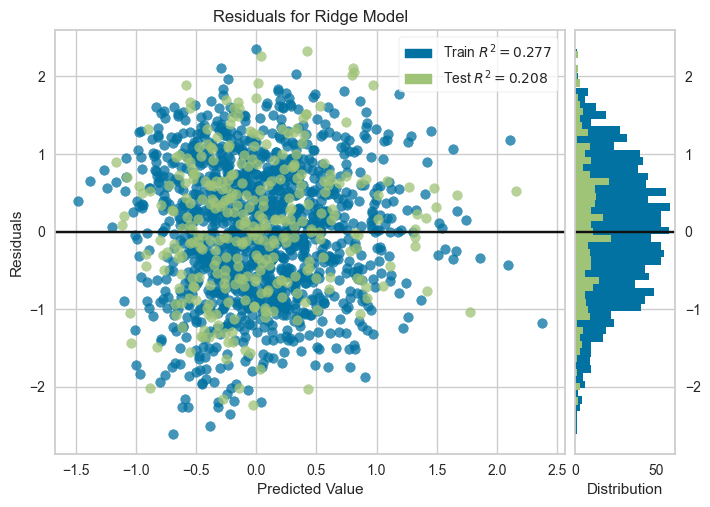

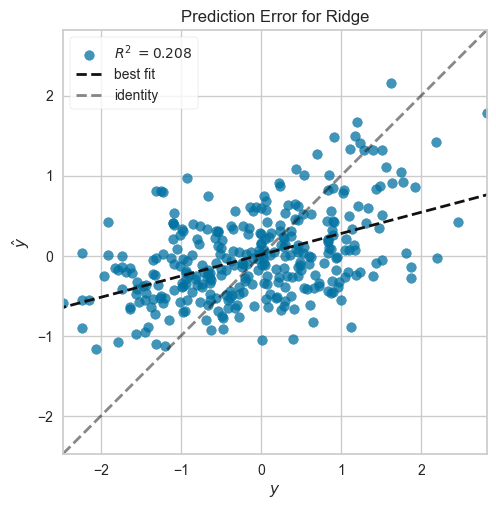

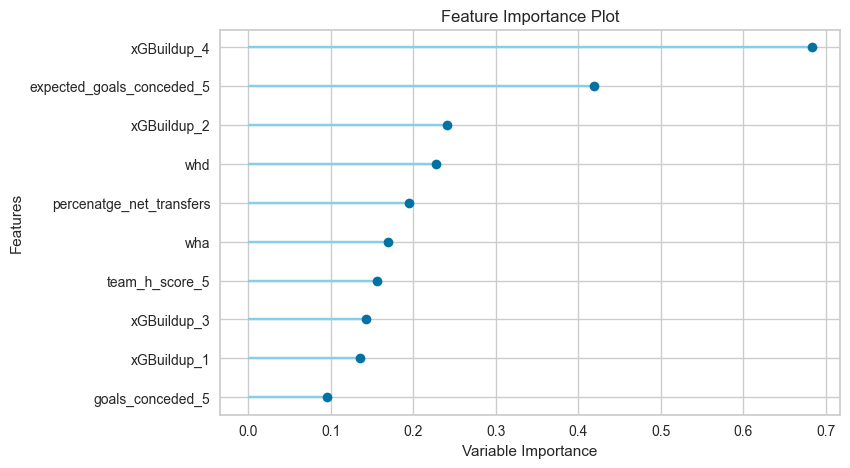

In [46]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [47]:
blend_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_xgc_best = compare_models(n_select=3, sort='MAE')
print(g_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
g_xgc_blended = blend_models(g_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3036
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 67
[LightGBM] [Info] Start training from score 0.021224


,Description,Value
0,Session id,5313
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 108)"
4,Transformed data shape,"(1612, 22)"
5,Transformed train set shape,"(1289, 22)"
6,Transformed test set shape,"(323, 22)"
7,Numeric features,106
8,Rows with missing values,17.4%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7007,0.7455,0.8618,0.2325,0.4005,1.8252,0.2960
lr,Linear Regression,0.7015,0.7472,0.8629,0.2305,0.4006,1.8407,0.3740
br,Bayesian Ridge,0.7027,0.7451,0.8615,0.2341,0.4058,1.7845,0.3570
gbr,Gradient Boosting Regressor,0.7038,0.7574,0.8687,0.2206,0.4103,1.8485,0.6340
rf,Random Forest Regressor,0.7043,0.7604,0.8700,0.2199,0.4075,1.8879,1.0370
et,Extra Trees Regressor,0.7075,0.7597,0.8700,0.2193,0.4056,1.8873,0.8040
ada,AdaBoost Regressor,0.7124,0.7676,0.8744,0.2122,0.4358,1.5656,0.4130
omp,Orthogonal Matching Pursuit,0.7192,0.7734,0.8779,0.2055,0.4192,1.8271,0.5460
en,Elastic Net,0.7193,0.7746,0.8785,0.2048,0.4270,1.7443,0.5000
llar,Lasso Least Angle Regression,0.7206,0.7779,0.8803,0.2018,0.4352,1.6679,0.2460


[Ridge(random_state=5313), LinearRegression(n_jobs=-1), BayesianRidge()]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6230,0.5889,0.7674,0.2993,0.3484,1.6144
1,0.6946,0.7525,0.8675,0.1688,0.3817,2.3744
2,0.7828,0.8838,0.9401,0.2331,0.4485,1.5118
3,0.7182,0.7719,0.8786,0.2632,0.4355,1.8317
4,0.7415,0.8387,0.9158,0.1240,0.4174,2.7637
5,0.7566,0.8556,0.9250,0.2379,0.4109,1.9439
6,0.6680,0.6665,0.8164,0.2184,0.3943,1.4937
7,0.6798,0.6796,0.8244,0.2549,0.3813,2.1793
8,0.6788,0.6849,0.8276,0.3807,0.4230,1.1074


### Save Model


In [48]:
g_xgc_final_model = finalize_model(g_xgc_blended)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=RemoveMulticollinearity(threshold=0.9))),
                 ('feature_selection',
         

## Def


expected_goals_conceded
0.00    79
0.83    75
1.03    57
1.48    56
1.08    47
        ..
9.84     1
6.86     1
6.94     1
3.06     1
3.07     1
Name: count, Length: 386, dtype: int64


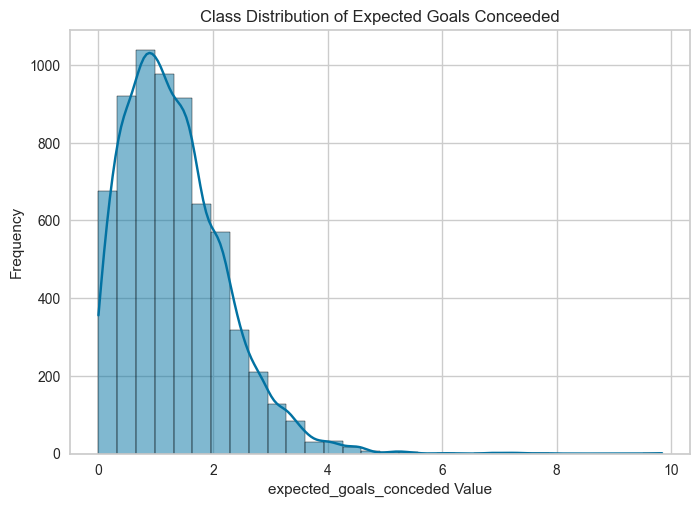

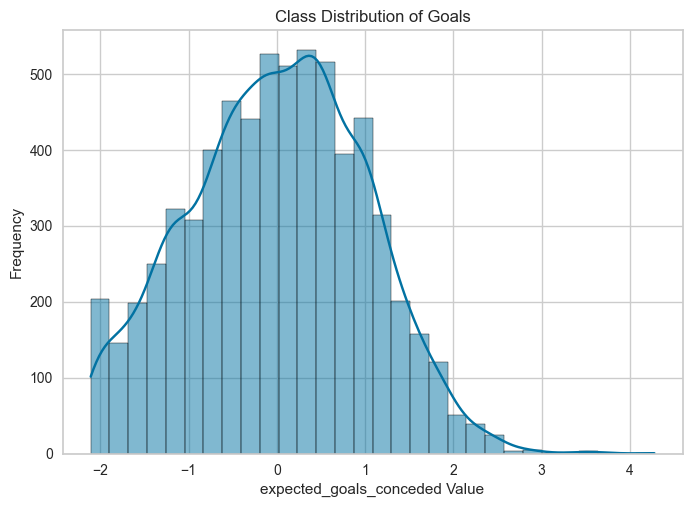

In [49]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(def_xgc_data[['expected_goals_conceded']])

def_xgc_data['expected_goals_conceded'] = pt.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6553
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 73
[LightGBM] [Info] Start training from score 0.007387


,Description,Value
0,Session id,5785
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 108)"
4,Transformed data shape,"(6573, 22)"
5,Transformed train set shape,"(5258, 22)"
6,Transformed test set shape,"(1315, 22)"
7,Numeric features,106
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6583,0.6891,0.8278,0.3057,0.4019,1.6918,2.3210
lightgbm,Light Gradient Boosting Machine,0.6709,0.7116,0.8426,0.2824,0.4006,1.8781,0.8320
rf,Random Forest Regressor,0.6831,0.7348,0.8558,0.2600,0.4191,1.7387,4.9650
xgboost,Extreme Gradient Boosting,0.6868,0.7591,0.8703,0.2343,0.3882,2.1968,0.8700
gbr,Gradient Boosting Regressor,0.7026,0.7586,0.8698,0.2361,0.4285,1.7844,1.5260
lr,Linear Regression,0.7644,0.8779,0.9363,0.1160,0.4591,1.7547,0.4850
ridge,Ridge Regression,0.7644,0.8777,0.9362,0.1162,0.4592,1.7523,0.7100
br,Bayesian Ridge,0.7650,0.8780,0.9364,0.1158,0.4622,1.7061,0.7700
ada,AdaBoost Regressor,0.7657,0.8789,0.9369,0.1146,0.5012,1.4477,0.9810
omp,Orthogonal Matching Pursuit,0.7975,0.9496,0.9740,0.0434,0.5162,1.4177,0.5690


ExtraTreesRegressor(n_jobs=-1, random_state=5785)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


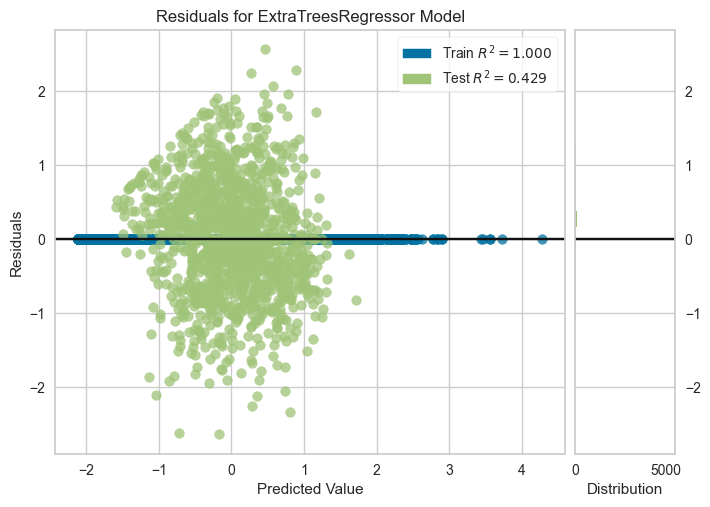

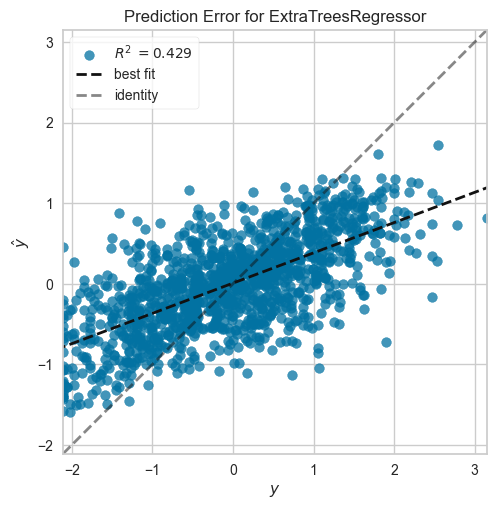

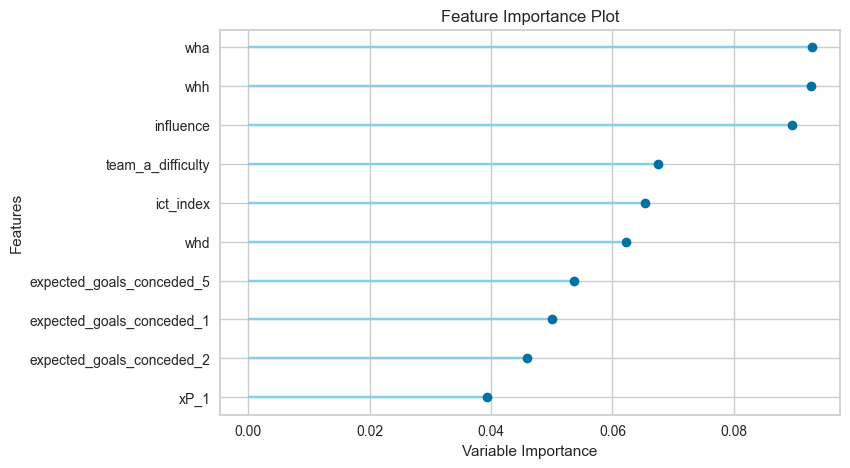

In [50]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [51]:
blend_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xgc_best = compare_models(n_select=3, sort='MAE')
print(def_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
def_xgc_blended = blend_models(def_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003526 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6519
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 73
[LightGBM] [Info] Start training from score 0.004062


,Description,Value
0,Session id,3566
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 108)"
4,Transformed data shape,"(6573, 22)"
5,Transformed train set shape,"(5258, 22)"
6,Transformed test set shape,"(1315, 22)"
7,Numeric features,106
8,Rows with missing values,16.9%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6237,0.6351,0.7950,0.3661,0.3786,1.8878,2.3740
lightgbm,Light Gradient Boosting Machine,0.6563,0.6837,0.8262,0.3169,0.3917,2.0280,0.7090
rf,Random Forest Regressor,0.6669,0.7053,0.8389,0.2953,0.4086,1.8159,4.9190
xgboost,Extreme Gradient Boosting,0.6746,0.7361,0.8572,0.2643,0.3803,2.4772,0.9320
gbr,Gradient Boosting Regressor,0.6892,0.7354,0.8570,0.2651,0.4170,1.8800,1.5570
ada,AdaBoost Regressor,0.7580,0.8635,0.9290,0.1370,0.5009,1.4458,1.0360
ridge,Ridge Regression,0.7605,0.8753,0.9353,0.1251,0.4545,1.8328,0.4830
lr,Linear Regression,0.7606,0.8753,0.9354,0.1250,0.4544,1.8339,0.6830
br,Bayesian Ridge,0.7608,0.8754,0.9354,0.1249,0.4570,1.8072,0.4900
en,Elastic Net,0.7980,0.9507,0.9748,0.0498,0.5296,1.3768,0.6850


[ExtraTreesRegressor(n_jobs=-1, random_state=3566), LGBMRegressor(n_jobs=-1, random_state=3566), RandomForestRegressor(n_jobs=-1, random_state=3566)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6839,0.7323,0.8558,0.2644,0.4222,1.3848
1,0.6920,0.7932,0.8906,0.2633,0.4289,1.4077
2,0.6346,0.6353,0.7971,0.3745,0.3819,1.6325
3,0.6687,0.7307,0.8548,0.2517,0.4167,1.6143
4,0.6072,0.5627,0.7502,0.4281,0.3787,1.4883
5,0.6051,0.5932,0.7702,0.3525,0.3809,3.5628
6,0.6225,0.6348,0.7967,0.3852,0.3792,1.7685
7,0.6330,0.6235,0.7896,0.3975,0.3813,2.0671
8,0.6463,0.6608,0.8129,0.3543,0.3817,1.8851


In [52]:
tuned_blend = tune_model(def_xgc_blended, optimize='MAE', n_iter=10)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6811,0.7283,0.8534,0.2685,0.4182,1.5184
1,0.6876,0.7821,0.8843,0.2736,0.4247,1.4913
2,0.6301,0.6277,0.7923,0.3821,0.3737,1.6560
3,0.6621,0.7169,0.8467,0.2658,0.4107,1.6454
4,0.5995,0.5542,0.7444,0.4368,0.3732,1.5576
5,0.6010,0.5855,0.7652,0.3608,0.3759,3.7022
6,0.6162,0.6262,0.7913,0.3935,0.3715,1.8496
7,0.6294,0.6168,0.7853,0.4040,0.3727,2.0744
8,0.6388,0.6520,0.8075,0.3629,0.3745,1.9639


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [53]:
def_xgc_final_model = finalize_model(tuned_blend)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                               